# Supplementary - Geometries

Contains analyses related to Supplementary Figure S1.

In [6]:
import sys
sys.path.append("..")

from main import *
from visualization import *

from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import sys
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from numba import njit
from scipy.stats import zscore

plt.rcParams['font.size'] = 18

if torch.cuda.is_available():  
    device = "cuda:0" 
else:  
    device = "cpu" 
    
print(device)

cuda:0


# Part 1: Inspecting single runs in geometries

## Geometry #1: Ellipsoid

In [ ]:
vertices = np.load('../Files/vertices_ellipse.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_ellipse.npy')

ellipse = Geometry(vertices, eigenmodes)

In [ ]:
params = {'N_neurons': 2500,
          'h': 0.1,
          'gamma': 25,
          'g': 5,
          'tau': 3,
          'dale': False,
          'rule': 'EDR'
          }

simulator = Simulator(ellipse,
                      ChaoticRNN,
                      params)

simulator.integrate(1000, output=False)

In [ ]:
%matplotlib inline
simulator.plot(spacing=1.5)

In [ ]:
%matplotlib inline
simulator.imshow()

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                  cmap='hot',
                  vmax=1.5)

In [ ]:
W_0 = numpify(simulator.dynamics.W)
C = simulator.compute_average_correlations(n_iters=50, T=2500, W_0=W_0)

In [ ]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='hot', vmin=0.1, vmax=0.3)

In [ ]:
mode_similarity, mapping, gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [ ]:
save = True
if save:
    np.save('../Results/supp_geometries_coordinates_ellipse.npy', simulator.coordinates)
    np.save('../Results/supp_geometries_matrix_ellipse.npy', mode_similarity)
    np.save('../Results/supp_geometries_mapping_ellipse.npy', mapping)
    np.save('../Results/supp_geometries_gradients_ellipse.npy', gradients)

## Geometry #2: Heart

In [ ]:
vertices = np.load('../Files/vertices_heart.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_heart.npy')

ellipse = Geometry(vertices, eigenmodes)

In [ ]:
params = {'N_neurons': 2500,
          'h': 0.1,
          'gamma': 25,
          'g': 5,
          'tau': 3,
          'dale': False,
          'rule': 'EDR'
          }

simulator = Simulator(ellipse,
                      ChaoticRNN,
                      params)

simulator.integrate(1000, output=False)

In [ ]:
%matplotlib inline
simulator.plot(spacing=1.5)

In [ ]:
%matplotlib inline
simulator.imshow(vmin=0, vmax=1)

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                  cmap='hot',
                  vmax=1.5,
                  elev=10)

In [ ]:
W_0 = numpify(simulator.dynamics.W)
C = simulator.compute_average_correlations(n_iters=50, T=2500, W_0=W_0)

In [ ]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='hot', vmin=0.1, vmax=0.3)

In [ ]:
mode_similarity, mapping, gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [ ]:
save = True
if save:
    np.save('../Results/supp_geometries_coordinates_heart.npy', simulator.coordinates)
    np.save('../Results/supp_geometries_matrix_heart.npy', mode_similarity)
    np.save('../Results/supp_geometries_mapping_heart.npy', mapping)
    np.save('../Results/supp_geometries_gradients_heart.npy', gradients)

## Geometry #3: Torus

In [ ]:
vertices = np.load('../Files/vertices_torus.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_torus.npy')

ellipse = Geometry(vertices, eigenmodes)

In [ ]:
params = {'N_neurons': 2500,
          'h': 0.1,
          'gamma': 25,
          'g': 5,
          'tau': 3,
          'dale': False,
          'rule': 'EDR'
          }

simulator = Simulator(ellipse,
                      ChaoticRNN,
                      params)

simulator.integrate(1000, output=False)

In [ ]:
%matplotlib inline
simulator.plot(spacing=1.5)

In [ ]:
%matplotlib inline
simulator.imshow()

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                  cmap='hot',
                  vmax=1.5)

In [ ]:
W_0 = numpify(simulator.dynamics.W)
C = simulator.compute_average_correlations(n_iters=50, T=2500, W_0=W_0)

In [ ]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='hot', vmin=0.1, vmax=0.3)

In [ ]:
mode_similarity, mapping, gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [ ]:
save = True
if save:
    np.save('../Results/supp_geometries_coordinates_torus.npy', simulator.coordinates)
    np.save('../Results/supp_geometries_matrix_torus.npy', mode_similarity)
    np.save('../Results/supp_geometries_mapping_torus.npy', mapping)
    np.save('../Results/supp_geometries_gradients_torus.npy', gradients)

## Geometry #4: Cow (Final boss)

In [9]:
vertices = np.load('../Files/vertices_cow.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_cow.npy')

ellipse = Geometry(vertices, eigenmodes)

In [34]:
params = {'N_neurons': 10000,
          'h': 0.05,
          'gamma': 35,
          'g': 5,
          'tau': 3,
          'dale': False,
          'rule': 'radius'
          }

simulator = Simulator(ellipse,
                      ChaoticRNN,
                      params)

simulator.integrate(1000, output=False)

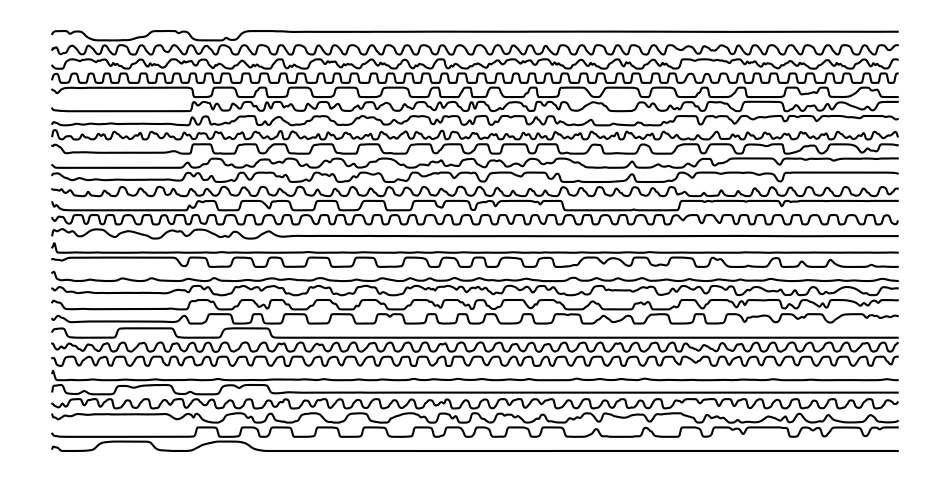

In [35]:
%matplotlib inline
simulator.plot(spacing=1.5)

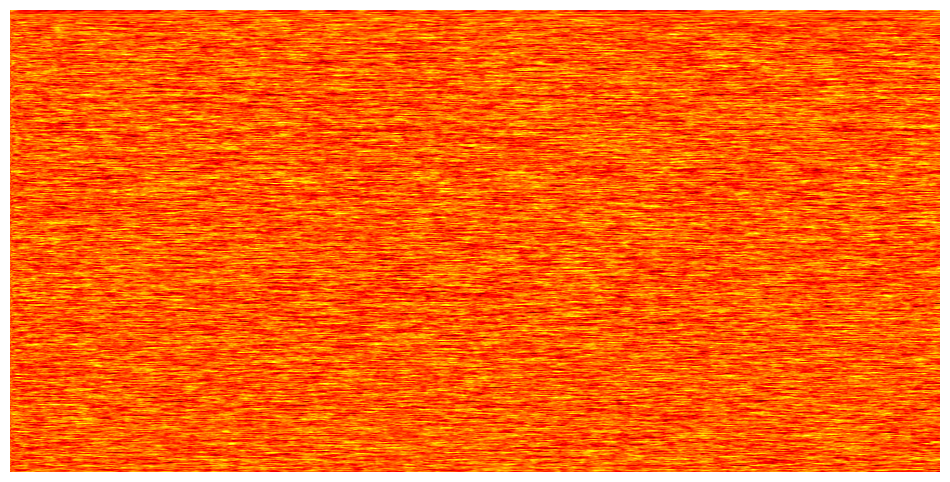

In [36]:
%matplotlib inline
simulator.imshow()

In [37]:
%matplotlib qt
simulator.animate(alpha=0.75,
                  cmap='hot',
                  vmax=1.5,
                  elev=10)

In [48]:
W_0 = numpify(simulator.dynamics.W)
C = simulator.compute_average_correlations(n_iters=100, T=500)

100%|█████████████████████████████████████████| 100/100 [08:54<00:00,  5.35s/it]


In [49]:
vmin, vmax = np.percentile(C, 5), np.percentile(C, 95)

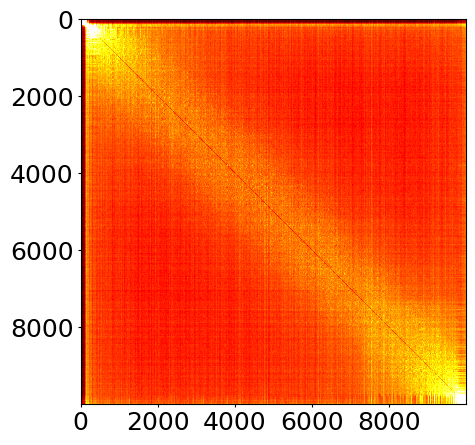

In [50]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='hot', vmin=vmin, vmax=vmax)

In [51]:
mode_similarity, mapping, gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

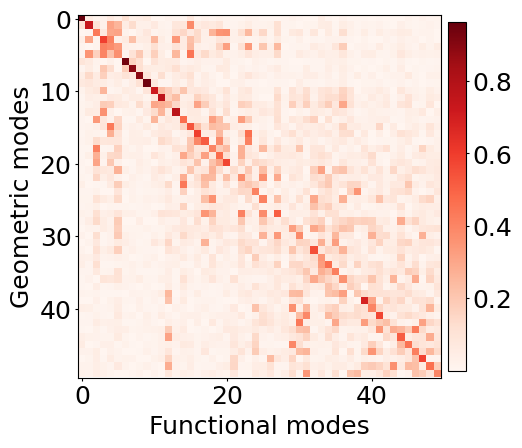

In [52]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [ ]:
save = True
if save:
    np.save('../Results/supp_geometries_coordinates_cow.npy', simulator.coordinates)
    np.save('../Results/supp_geometries_matrix_cow.npy', mode_similarity)
    np.save('../Results/supp_geometries_mapping_cow.npy', mapping)
    np.save('../Results/supp_geometries_gradients_cow.npy', gradients)

# Part 2: Averaging multiple runs (Compute Canada)

This is done on a remote server (Compute Canada). See the code in the `ComputeCanada/geometries/` folder.

# Part 3: Generating figure

In [2]:
from visualization import *

In [ ]:
coords, matrix, mapping, gradients = [], [], [], []

for geo in ['ellipse', 'heart', 'torus', 'cow']:

    coords.append(np.load(f'../Results/supp_geometries_coordinates_{geo}.npy'))
    matrix.append(np.load(f'../Results/supp_geometries_matrix_{geo}.npy'))
    mapping.append(np.load(f'../Results/supp_geometries_mapping_{geo}.npy'))
    gradients.append(np.load(f'../Results/supp_geometries_gradients_{geo}.npy'))

Averaged matrices from Compute Canada

In [2]:
matrices = [np.load('../ComputeCanada/geometries/mode_similarity_ellipsoid.npy'),
            np.load('../ComputeCanada/geometries/mode_similarity_heart.npy'),
            np.load('../ComputeCanada/geometries/mode_similarity_torus.npy'),
            np.load('../ComputeCanada/geometries/mode_similarity_cow.npy')]

#### Ellipse images

First, we generate .png images of the 3D scatter plots of each geometry, as they are easier to work with once rendered in bitmaps.

In [ ]:
vertices = np.load('../Files/vertices_ellipse.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_ellipse.npy')

geometry = Geometry(vertices, eigenmodes)
geometry.vertices -= np.mean(geometry.vertices, axis=0)

In [ ]:
figs_ellipse_gradients = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(coords[0][:, 0] + 0.5, coords[0][:, 1] + 0.5, coords[0][:, 2] + 0.5, c=np.sign(matrix[0][i, i]) * gradients[0][mapping[0][i]], alpha=0.5, cmap='coolwarm', edgecolor='None', s=75)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_ellipse_gradients.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_ellipse_gradients[0])
plt.axis('off')

In [ ]:
figs_ellipse_eigenmodes = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], c=eigenmodes.T[i+1], alpha=0.5, cmap='coolwarm', edgecolor='None')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_ellipse_eigenmodes.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_ellipse_eigenmodes[0])
plt.axis('off')

#### Heart images

In [ ]:
vertices = np.load('../Files/vertices_heart.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_heart.npy')

geometry = Geometry(vertices, eigenmodes)
geometry.vertices -= np.mean(geometry.vertices, axis=0)

In [ ]:
figs_heart_gradients = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(coords[1][:, 0] + 0.5, coords[1][:, 1] + 0.5, coords[1][:, 2] + 0.5, c=np.sign(matrix[1][i, i]) * gradients[1][mapping[1][i]], alpha=0.5, cmap='coolwarm', edgecolor='None', s=75)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_heart_gradients.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_heart_gradients[0])
plt.axis('off')
plt.show()

In [ ]:
figs_heart_eigenmodes = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], c=eigenmodes.T[i+1], alpha=0.5, cmap='coolwarm', edgecolor='None')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_heart_eigenmodes.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_heart_eigenmodes[0])
plt.axis('off')

#### Torus images

In [ ]:
vertices = np.load('../Files/vertices_torus.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_torus.npy')

geometry = Geometry(vertices, eigenmodes)
geometry.vertices -= np.mean(geometry.vertices, axis=0)

In [ ]:
figs_torus_gradients = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(coords[2][:, 0] + 0.5, coords[2][:, 1] + 0.5, coords[2][:, 2] + 0.5, c=np.sign(matrix[2][i, i]) * gradients[2][mapping[2][i]], alpha=0.5, cmap='coolwarm', edgecolor='None', s=75)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_torus_gradients.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_torus_gradients[0])
plt.axis('off')

In [ ]:
figs_torus_eigenmodes = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], c=eigenmodes.T[i+1], alpha=0.5, cmap='coolwarm', edgecolor='None')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    plt.tight_layout(pad=0)
    figs_torus_eigenmodes.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_torus_eigenmodes[0])
plt.axis('off')

#### Cow images

In [ ]:
vertices = np.load('../Files/vertices_cow.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_cow.npy')

geometry = Geometry(vertices, eigenmodes)
geometry.vertices -= np.mean(geometry.vertices, axis=0)

In [ ]:
figs_cow_gradients = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(coords[3][:, 0] + 0.5, coords[3][:, 1] + 0.5, coords[3][:, 2] + 0.5, c=np.sign(matrix[3][i, i]) * gradients[3][mapping[3][i]], alpha=0.5, cmap='coolwarm', edgecolor='None', s=75)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    ax.view_init(elev=-10, azim=135)
    plt.tight_layout(pad=0)
    figs_cow_gradients.append(figure_to_array(fig))
    plt.close()

In [ ]:
plt.imshow(figs_cow_gradients[0])
plt.axis('off')

In [ ]:
figs_cow_eigenmodes = []
for i in range(10):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(5, 5), dpi=300)
    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], c=eigenmodes.T[i+1], alpha=0.5, cmap='coolwarm', edgecolor='None')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_zlim([0, 1])
    ax.set_axis_off()
    ax.view_init(elev=-10, azim=135)

    plt.tight_layout(pad=0)
    figs_cow_eigenmodes.append(figure_to_array(fig))
    plt.close()

#### Rendering multi-panel figure

In [3]:
def zoom_crop(array, factor=2, x_offset=0, y_offset=0):
    if factor != 1:
        L = array.shape[0]
        delta = int((1 - (1 / factor)) * L / 2)
        return array[delta+y_offset:-delta+y_offset, delta+x_offset:-delta+x_offset, :]
    else:
        return array

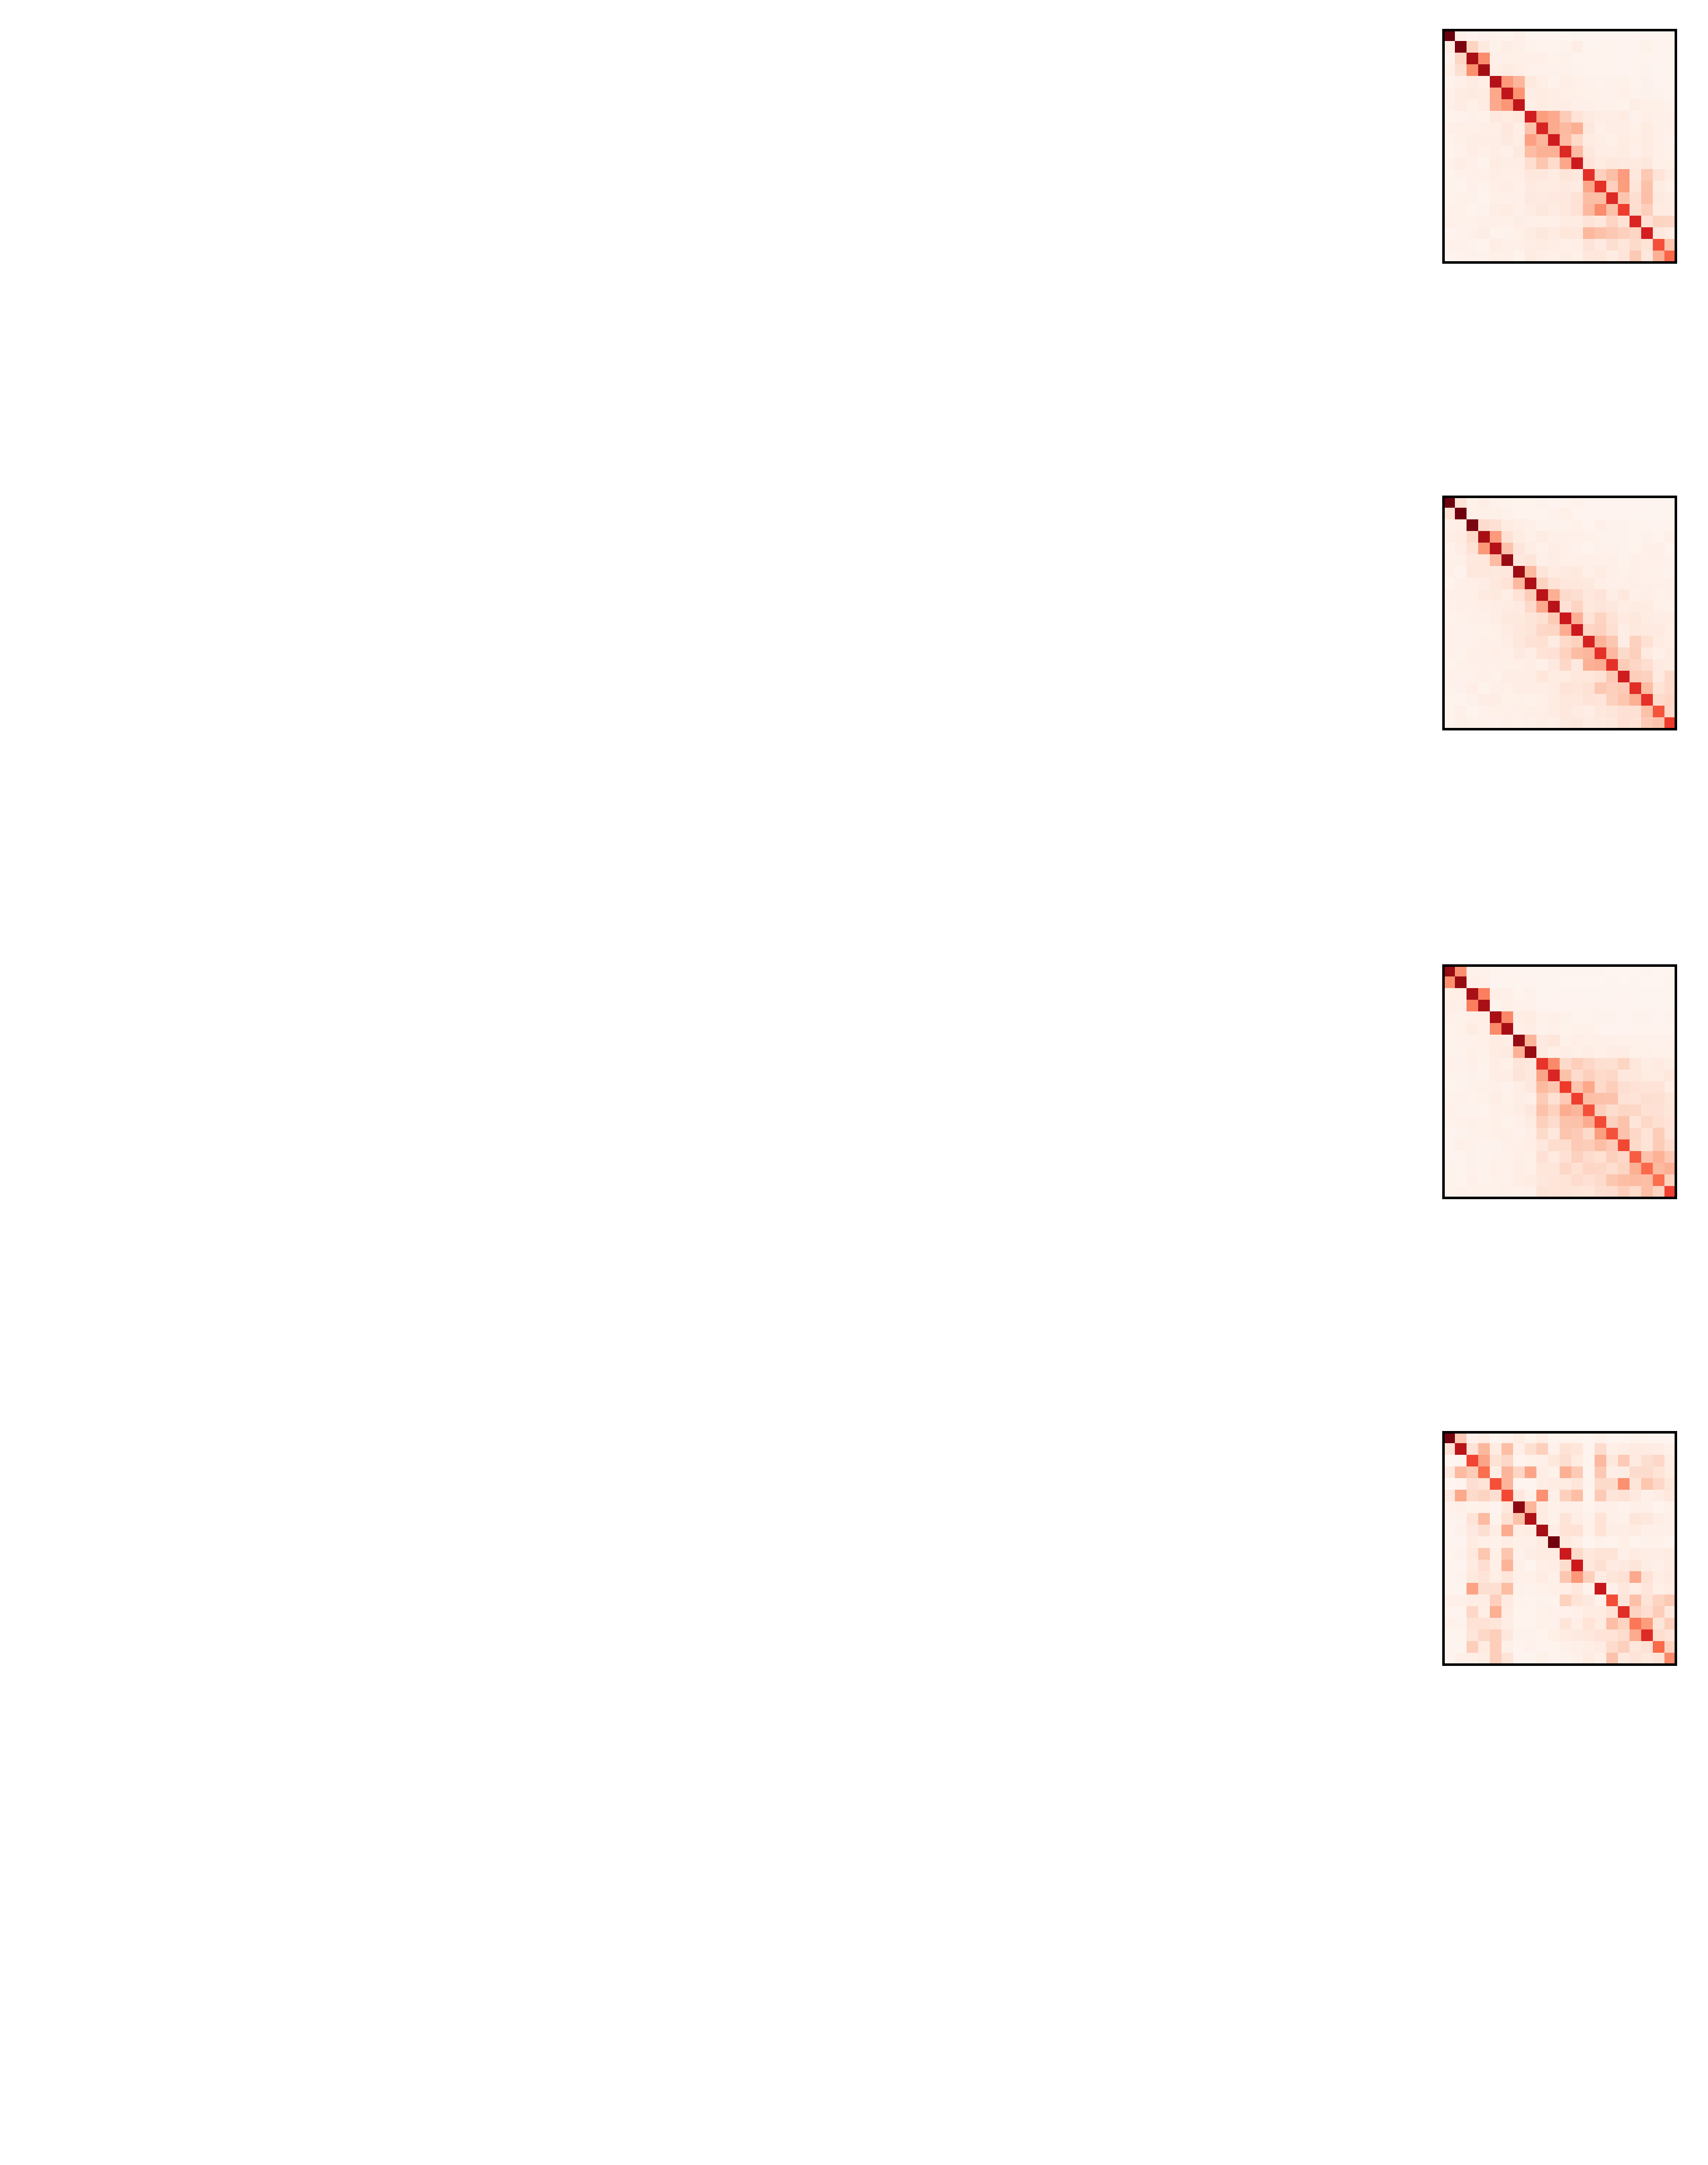

In [7]:
fig = PaperFigure(figsize=(7, 9))

fig.set_tick_length(2)
fig.set_font_size(6)
fig.add_background()


N_modes = 10
w = 5.5 / N_modes
ratio = 1
pad = 0

y = 0
for i in range(N_modes):
    fig.add_axes('gradients_ellipse{}'.format(i), (i * (w + pad), y), w, w * ratio)
    fig.add_axes('modes_ellipse{}'.format(i), (i * (w + pad), y + w * ratio + 0.1), w, w * ratio)

y = 2
for i in range(N_modes):
    fig.add_axes('gradients_heart{}'.format(i), (i * (w + pad), y), w, w * ratio)
    fig.add_axes('modes_heart{}'.format(i), (i * (w + pad), y + w * ratio + 0.1), w, w * ratio)

y = 4
for i in range(N_modes):
    fig.add_axes('gradients_torus{}'.format(i), (i * (w + pad), y), w, w * ratio)
    fig.add_axes('modes_torus{}'.format(i), (i * (w + pad), y + w * ratio + 0.1), w, w * ratio)

y = 6
for i in range(N_modes):
    fig.add_axes('gradients_cow{}'.format(i), (i * (w + pad), y), w, w * ratio)
    fig.add_axes('modes_cow{}'.format(i), (i * (w + pad), y + w * ratio + 0.1), w, w * ratio)

fig.add_axes('matrix_ellipse', (6, 0), 1, 1)
fig.add_axes('matrix_heart', (6, 2), 1, 1)
fig.add_axes('matrix_torus', (6, 4), 1, 1)
fig.add_axes('matrix_cow', (6, 6), 1, 1)

fig.set_line_thickness(0.6)

# --------------------------------------------------------------------------------------------------

zoom_factors = [1.75, 1.4, 1.4, 1.75]
offsets = [0, 0, 0, 0]
#figs_gradients = [figs_ellipse_gradients, figs_heart_gradients, figs_torus_gradients, figs_cow_gradients]
#figs_eigenmodes = [figs_ellipse_eigenmodes, figs_heart_eigenmodes, figs_torus_eigenmodes, figs_cow_eigenmodes]
geometries = ['ellipse', 'heart', 'torus', 'cow']

for j in range(len(geometries)):

    ax = fig.axes[f'matrix_{geometries[j]}']
    #ax.imshow(np.abs(matrix[j])[:20, :20], cmap='Reds', vmin=0, vmax=1)
    ax.imshow(np.mean(np.abs(matrices[j]), axis=0)[:20, :20], cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(N_modes):
        ax = fig.axes[f'gradients_{geometries[j]}{i}']
        #ax.imshow(zoom_crop(figs_gradients[j][i], factor=zoom_factors[j], x_offset=offsets[j]))
        ax.axis('off')
    
        ax = fig.axes[f'modes_{geometries[j]}{i}']
        #ax.imshow(zoom_crop(figs_eigenmodes[j][i], factor=zoom_factors[j], x_offset=offsets[j]))
        ax.axis('off')

fig.show()

In [9]:
fig.save('../Figures/supp_geometries_incomplete.svg')

#### Manually written values

In [ ]:
print(np.abs(np.diag(matrix[0]))[:10])

In [ ]:
print(np.abs(np.diag(matrix[1]))[:10])

In [ ]:
print(np.abs(np.diag(matrix[2]))[:10])

In [ ]:
print(np.abs(np.diag(matrix[3]))[:10])